In [15]:
"""
Baseline ResNet-50 for Thoracic Disease Classification
Based on: El-Fiky et al. (2021) - Multi-Label Transfer Learning

This notebook implements the baseline ResNet-50 model using transfer learning
methodology from the paper to achieve comparable performance (AUC: 0.911, F1: 0.66)
"""
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, hamming_loss, roc_curve
import warnings
warnings.filterwarnings('ignore')
import tensorflow_addons as tfa


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
# ============================================================================
# CONFIGURATION - Following El-Fiky et al. (2021) Paper
# ============================================================================

# Dataset configuration
IMAGE_SIZE = 224  # Paper uses 224x224
BATCH_SIZE = 32   # Paper uses batch size 32
EPOCHS = 60       # Paper uses 60 epochs
LEARNING_RATE = 0.001  # Paper uses 0.001

print(f"\nConfiguration:")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")


Configuration:
  Image Size: 224x224
  Batch Size: 32
  Epochs: 60
  Learning Rate: 0.001


In [ ]:
# ============================================================================
# DATASET CONFIGURATION AND LOADING - WITH DATASET SELECTION
# ============================================================================

#d DATASET SELECTION - Choose which dataset to use
USE_COMBINED_DATASET = False  # Set to False to use original dataset only

if USE_COMBINED_DATASET:
    BASE_DIR = "./combined_dataset/"
    CSV_PATH = os.path.join(BASE_DIR, "combined_pneumothorax.csv")
    IMAGE_DIR = os.path.join(BASE_DIR, "images")
    dataset_name = "COMBINED (dataset_pneumothorax + dataset_pneumothorax_small)"
else:
    BASE_DIR = "./dataset_pneumothorax/"
    CSV_PATH = os.path.join(BASE_DIR, "pneumothorax.csv")
    IMAGE_DIR = os.path.join(BASE_DIR, "images")
    dataset_name = "ORIGINAL (dataset_pneumothorax only)"

print(f"Loading {dataset_name}...")

# Load the dataset CSV
try:
    df = pd.read_csv(CSV_PATH)
    print(f"✓ Loaded CSV with {len(df):,} total images")
except Exception as e:
    print(f"✗ Error reading CSV {CSV_PATH}: {e}")
    if USE_COMBINED_DATASET:
        print(f"\n💡 Did you run the combined.py script first?")
        print(f"   Run: python combined.py")
    exit(1)

# Display CSV structure
print(f"\n=== Dataset Structure ===")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

# Use Binary_Label column
if 'Binary_Label' in df.columns:
    df['binary_label'] = df['Binary_Label']
elif 'Pneumothorax' in df.columns:
    df['binary_label'] = df['Pneumothorax'].astype(int)
else:
    print("✗ Could not find Pneumothorax labels")
    exit(1)

# Create full image paths
df['path'] = df['Image_Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))

# Verify images exist
df['exists'] = df['path'].apply(os.path.exists)
missing_count = (~df['exists']).sum()

if missing_count > 0:
    print(f"\n⚠ Warning: {missing_count} images not found")
    df = df[df['exists']].copy()

df = df.drop(columns=['exists'])
balanced_df = df.copy()

# Display source breakdown (if available)
if USE_COMBINED_DATASET and 'source' in df.columns:
    print(f"\n=== Dataset Source Breakdown ===")
    source_counts = df['source'].value_counts()
    for source, count in source_counts.items():
        print(f"  {source}: {count:,} images ({count/len(df)*100:.1f}%)")

print(f"\n=== Final Dataset Summary ===")
print(f"Dataset: {dataset_name}")
print(f"Total images: {len(df):,}")
print(f"Pneumothorax (Positive): {df['binary_label'].sum():,} ({df['binary_label'].sum()/len(df)*100:.1f}%)")
print(f"No Pneumothorax (Negative): {(len(df) - df['binary_label'].sum()):,} ({(len(df) - df['binary_label'].sum())/len(df)*100:.1f}%)")

# Calculate balance ratio
pos_count = df['binary_label'].sum()
neg_count = len(df) - pos_count
balance_ratio = pos_count / neg_count if neg_count > 0 else 0
print(f"Balance ratio: 1:{1/balance_ratio:.2f}")

print(f"\n✅ Dataset is ready for training!")

Loading ORIGINAL (dataset_pneumothorax only)...
✓ Loaded CSV with 10,604 total images

=== Dataset Structure ===
Columns: ['Image_Index', 'Finding_Labels', 'Pneumothorax', 'Path', 'Binary_Label']

First 3 rows:
        Image_Index                      Finding_Labels  Pneumothorax  \
0  00001974_002.png           Infiltration|Pneumothorax             1   
1  00012620_013.png  Atelectasis|Consolidation|Effusion             0   
2  00014870_000.png                  Consolidation|Mass             0   

                      Path  Binary_Label  
0  images\00001974_002.png             1  
1  images\00012620_013.png             0  
2  images\00014870_000.png             0  

=== Final Dataset Summary ===
Dataset: ORIGINAL (dataset_pneumothorax only)
Total images: 10,604
Pneumothorax (Positive): 5,302 (50.0%)
No Pneumothorax (Negative): 5,302 (50.0%)
Balance ratio: 1:1.00

✅ Dataset is ready for training!


In [18]:
# Cell 4: Dataset Splitting with Stratification
# Path already exists from Cell 2, just use balanced_df directly
print(f"Dataset ready for splitting: {len(balanced_df)} samples")

# Stratified train-validation split (90/10)
train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.1,
    random_state=42,
    stratify=balanced_df['binary_label']
)

print(f"\n=== Dataset Splits (Stratified) ===")
print(f"Training set: {len(train_df):,} samples")
print(f"  Positive: {train_df['binary_label'].sum():,} ({train_df['binary_label'].sum()/len(train_df)*100:.1f}%)")
print(f"  Negative: {len(train_df) - train_df['binary_label'].sum():,} ({(len(train_df) - train_df['binary_label'].sum())/len(train_df)*100:.1f}%)")

print(f"\nValidation set: {len(val_df):,} samples")
print(f"  Positive: {val_df['binary_label'].sum():,} ({val_df['binary_label'].sum()/len(val_df)*100:.1f}%)")
print(f"  Negative: {len(val_df) - val_df['binary_label'].sum():,} ({(len(val_df) - val_df['binary_label'].sum())/len(val_df)*100:.1f}%)")

Dataset ready for splitting: 10604 samples

=== Dataset Splits (Stratified) ===
Training set: 9,543 samples
  Positive: 4,772 (50.0%)
  Negative: 4,771 (50.0%)

Validation set: 1,061 samples
  Positive: 530 (50.0%)
  Negative: 531 (50.0%)


In [19]:
# ============================================================================
# TF.DATA PIPELINE - CLAHE + TF AUGMENTATION (for CXR)
# ============================================================================
import tensorflow as tf
import numpy as np
import cv2

def apply_clahe(img):
    """Apply CLAHE to a single image tensor (H, W, 3) -> (H, W, 1)"""
    img = img.numpy()  # Eager tensor -> NumPy
    if img.max() <= 1.0:
        img = (img * 255).astype('uint8')
    else:
        img = img.astype('uint8')

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl_img = clahe.apply(gray)
    return cl_img.astype('float32')[..., None]  # (H, W, 1)


def create_tf_dataset(df, batch_size, image_size, shuffle=True, augment=True):
    """tf.data pipeline for binary classification with CLAHE preprocessing."""

    def load_and_preprocess(image_path, label):
        # Load image
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.cast(img, tf.float32)

        # Apply CLAHE (OpenCV, wrapped for TF)
        img = tf.py_function(func=apply_clahe, inp=[img], Tout=tf.float32)
        img.set_shape([None, None, 1])

        # Resize to model input size
        img = tf.image.resize(img, [image_size, image_size])

        # Convert grayscale to RGB (for ResNet compatibility)
        img = tf.image.grayscale_to_rgb(img)

        if augment:
            # Apply light augmentations for CXR
            img = tf.image.random_flip_left_right(img)
            # Optional: rotation or zoom (use tfa.image if installed)

        # Normalize for ResNet50V2
        img = tf.keras.applications.resnet_v2.preprocess_input(img)

        return img, label

    image_paths = df['path'].values
    labels = df['binary_label'].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=42)

    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


# Example usage:
print("Creating tf.data pipelines with CLAHE preprocessing...")
train_dataset = create_tf_dataset(train_df, BATCH_SIZE, IMAGE_SIZE, shuffle=True, augment=True)
val_dataset = create_tf_dataset(val_df, BATCH_SIZE, IMAGE_SIZE, shuffle=False, augment=False)

print("✅ tf.data pipelines created successfully")


Creating tf.data pipelines with CLAHE preprocessing...
✅ tf.data pipelines created successfully


In [ ]:
# ============================================================================
# MODEL ARCHITECTURE - ResNet-50 Transfer Learning (Paper Methodology)
# ============================================================================

def create_baseline_resnet50(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
):
    """
    Create baseline ResNet-50 model following El-Fiky et al. (2021)
    
    Paper methodology:
    - Uses ResNet-50 pre-trained on ImageNet
    - Fine-tunes all layers
    - Replaces FC layer with 15 neurons (14 diseases + No Finding)
    - Uses sigmoid activation for multi-label classification
    """
    
    # Load ResNet-50 pre-trained on ImageNet
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        pooling='avg'  # Global average pooling as per paper
    )
    
    base_model.trainable = False # Fine tune everything as per el fiky
    
    # Build model
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    
    # Paper replaces FC layer with custom layer
    # No additional dense layers mentioned - direct to output
    outputs = layers.Dense(
        1, 
        activation='sigmoid',  # Sigmoid for multi-label as per paper
        name='predictions'
    )(x)
    
    model = keras.Model(inputs, outputs, name='PneuModel')
    
    return model

print("\nCreating Baseline ResNet-50 model...")
model = create_baseline_resnet50()

# Model summary
print(f"\nModel Architecture:")
print(f"  Total parameters: {model.count_params():,}")
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f"  Trainable parameters: {trainable_params:,}")


Creating Baseline ResNet-50 model...



Model Architecture:
  Total parameters: 23,566,849
  Trainable parameters: 2,049


In [21]:
# ============================================================================
# MODEL COMPILATION - Following Paper Configuration
# ============================================================================

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',  # Paper uses binary cross-entropy
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc', multi_label=True),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("\nModel compiled with:")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Loss: binary_crossentropy")
print(f"  Metrics: binary_accuracy, AUC, precision, recall")


Model compiled with:
  Optimizer: Adam (lr=0.001)
  Loss: binary_crossentropy
  Metrics: binary_accuracy, AUC, precision, recall


In [22]:
# ============================================================================
# CALLBACKS
# ============================================================================

# Create output directory
os.makedirs('./output', exist_ok=True)

callbacks = [
    # Model checkpoint - save best model
    ModelCheckpoint(
        filepath='./output/baseline_resnet50_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    
    # Early stopping - prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        mode='min',
        restore_best_weights=True,
        verbose=1
    ),
    
    # Learning rate reduction
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [23]:
# ============================================================================
# TRAINING WITH CLASS WEIGHTS
# ============================================================================

print("\n" + "="*80)
print("STARTING TRAINING - Baseline ResNet-50 with Class Weights")
print("="*80)
print(f"Target Performance (from paper):")
print(f"  Average AUC: 0.911")
print(f"  Micro F1-score: 0.66")
print(f"  Hamming Loss: 0.404")
print("="*80 + "\n")

# # Calculate class weights to handle imbalance
# from sklearn.utils.class_weight import compute_class_weight

# # Get class weights
# y_train = train_df['binary_label'].values
# class_weights_array = compute_class_weight(
#     'balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )
# class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}

# print(f"📊 Class Weights (to balance training):")
# print(f"  Negative (0): {class_weights[0]:.3f}")
# print(f"  Pneumothorax (1): {class_weights[1]:.3f}")
# print(f"  → This penalizes missing pneumothorax cases more!\n")

# Train with class weights
history = model.fit(
    train_dataset,  
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Save final model
model.save('./output/baseline_resnet50_final.keras')
print("\nFinal model saved to: ./output/baseline_resnet50_final.keras")


STARTING TRAINING - Baseline ResNet-50 with Class Weights
Target Performance (from paper):
  Average AUC: 0.911
  Micro F1-score: 0.66
  Hamming Loss: 0.404

Epoch 1/60
298/299 [============================>.] - ETA: 0s - loss: 0.6387 - binary_accuracy: 0.6489 - auc: 0.7009 - precision: 0.6492 - recall: 0.6473
Epoch 1: val_auc improved from -inf to 0.77567, saving model to ./output\baseline_resnet50_best.keras
299/299 [==============================] - 106s 347ms/step - loss: 0.6386 - binary_accuracy: 0.6490 - auc: 0.7011 - precision: 0.6495 - recall: 0.6473 - val_loss: 0.5978 - val_binary_accuracy: 0.6701 - val_auc: 0.7757 - val_precision: 0.6243 - val_recall: 0.8528 - lr: 0.0010
Epoch 2/60
298/299 [============================>.] - ETA: 0s - loss: 0.5780 - binary_accuracy: 0.7008 - auc: 0.7680 - precision: 0.6973 - recall: 0.7095
Epoch 2: val_auc improved from 0.77567 to 0.79382, saving model to ./output\baseline_resnet50_best.keras
299/299 [==============================] - 102s 33

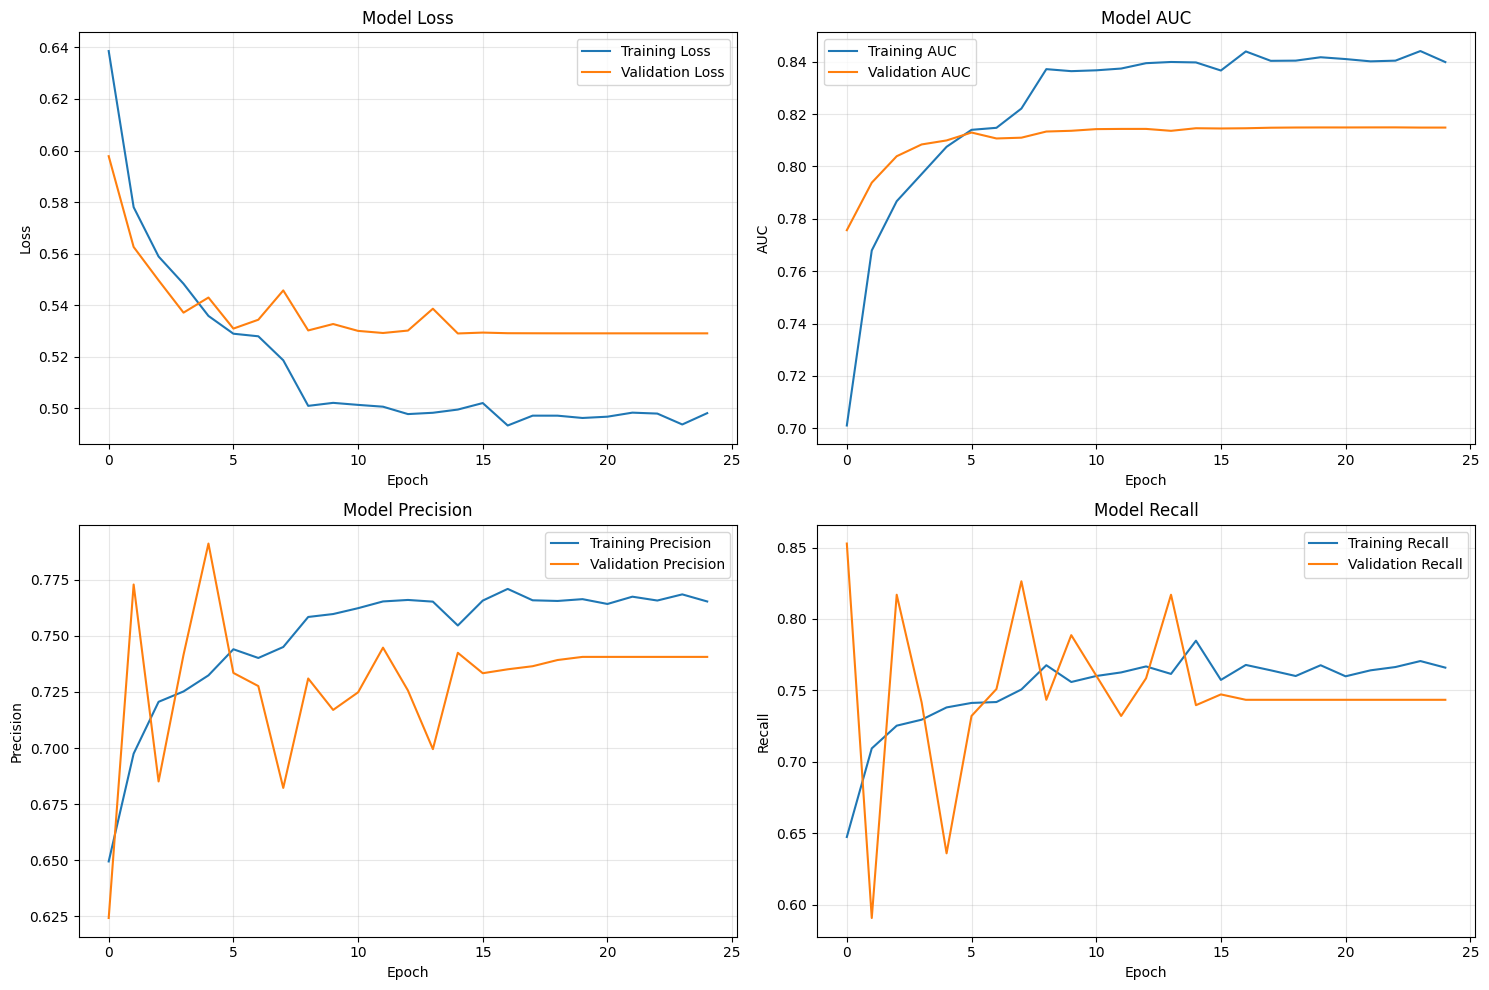

In [24]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # AUC
    axes[0, 1].plot(history.history['auc'], label='Training AUC')
    axes[0, 1].plot(history.history['val_auc'], label='Validation AUC')
    axes[0, 1].set_title('Model AUC')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/baseline_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

In [25]:
# ============================================================================
# COMPREHENSIVE EVALUATION - BINARY CLASSIFICATION
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION")
print("="*80)

# Generate predictions on validation dataset
print("Generating predictions on validation set...")
val_predictions = model.predict(val_dataset, verbose=1)

# Get true labels from validation dataframe - FIXED
y_true = val_df['binary_label'].values  # Use binary_label column
y_pred_probs = val_predictions.flatten()  # Flatten to 1D array
y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary predictions

print(f"\nPredictions shape: {y_pred_probs.shape}")
print(f"True labels shape: {y_true.shape}")
print(f"Unique predictions: {np.unique(y_pred)}")
print(f"Unique true labels: {np.unique(y_true)}")

# Calculate metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# AUC Score
auc_score = roc_auc_score(y_true, y_pred_probs)
print(f"\n📊 VALIDATION METRICS:")
print(f"  AUC Score: {auc_score:.4f}")

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['No Pneumothorax', 'Pneumothorax']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\n🔢 Confusion Matrix:")
print(f"  True Negatives: {cm[0,0]}")
print(f"  False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}")
print(f"  True Positives: {cm[1,1]}")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f"\n📈 Detailed Metrics:")
print(f"  Sensitivity (Recall): {sensitivity:.4f}")
print(f"  Specificity: {specificity:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  F1-Score: {f1_score:.4f}")
print(f"  Accuracy: {(tp + tn) / (tp + tn + fp + fn):.4f}")


COMPREHENSIVE EVALUATION
Generating predictions on validation set...
34/34 [==============================] - 12s 300ms/step

Predictions shape: (1061,)
True labels shape: (1061,)
Unique predictions: [0 1]
Unique true labels: [0 1]

📊 VALIDATION METRICS:
  AUC Score: 0.8147

📋 Classification Report:
                 precision    recall  f1-score   support

No Pneumothorax       0.74      0.74      0.74       531
   Pneumothorax       0.74      0.74      0.74       530

       accuracy                           0.74      1061
      macro avg       0.74      0.74      0.74      1061
   weighted avg       0.74      0.74      0.74      1061


🔢 Confusion Matrix:
  True Negatives: 395
  False Positives: 136
  False Negatives: 138
  True Positives: 392

📈 Detailed Metrics:
  Sensitivity (Recall): 0.7396
  Specificity: 0.7439
  Precision: 0.7424
  F1-Score: 0.7410
  Accuracy: 0.7418


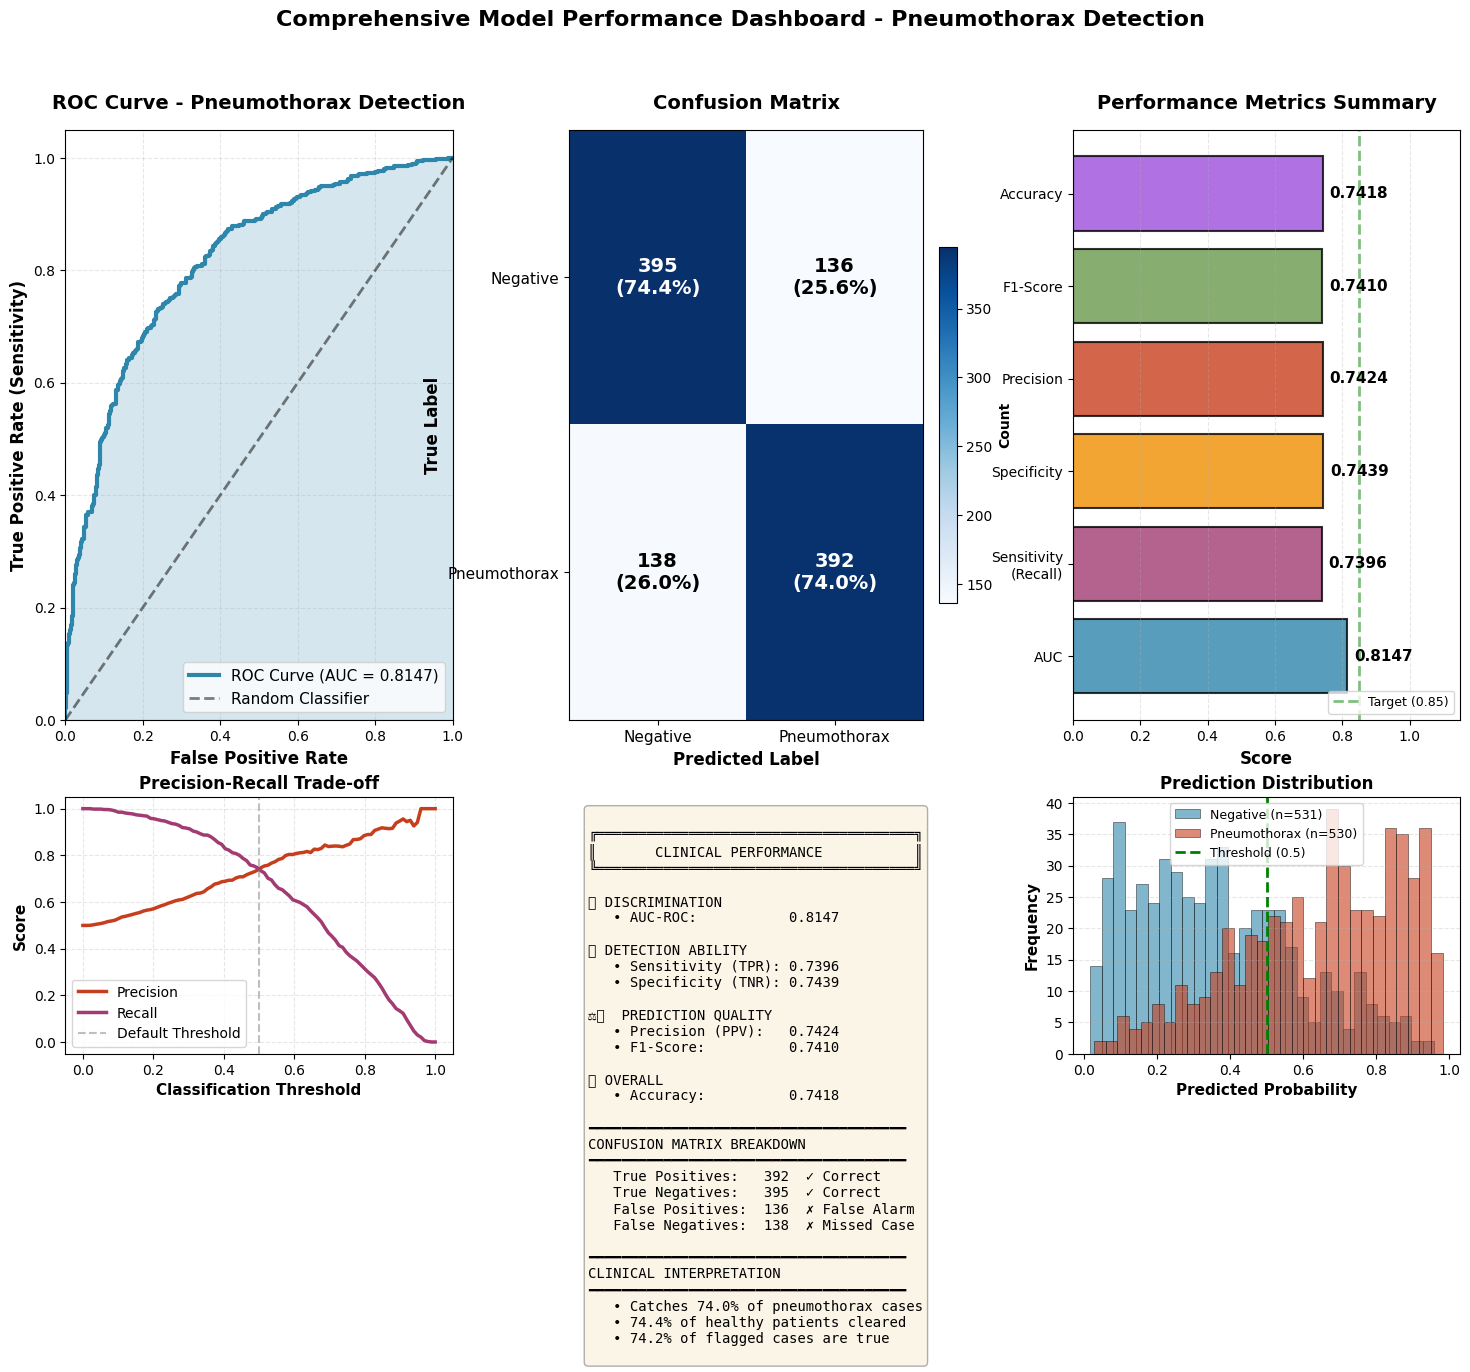


✅ Comprehensive metrics dashboard saved to:
   ./output/comprehensive_metrics_dashboard.png


In [26]:
# ============================================================================
# VISUAL METRICS DASHBOARD - AUC, PRECISION, RECALL, F1-SCORE
# ============================================================================

from sklearn.metrics import roc_curve, auc as sklearn_auc
import matplotlib.patches as mpatches

# Calculate all metrics
auc_score = roc_auc_score(y_true, y_pred_probs)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)
accuracy = (tp + tn) / (tp + tn + fp + fn)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# ============================================================================
# CREATE COMPREHENSIVE VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ============================================================================
# 1. ROC CURVE (Top Left - Large)
# ============================================================================
ax1 = fig.add_subplot(gs[0:2, 0])
ax1.plot(fpr, tpr, color='#2E86AB', linewidth=3, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Random Classifier')
ax1.fill_between(fpr, tpr, alpha=0.2, color='#2E86AB')
ax1.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax1.set_title('ROC Curve - Pneumothorax Detection', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])

# ============================================================================
# 2. CONFUSION MATRIX (Top Middle - Large)
# ============================================================================
ax2 = fig.add_subplot(gs[0:2, 1])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax2.imshow(cm, interpolation='nearest', cmap='Blues', aspect='auto')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Negative', 'Pneumothorax'], fontsize=11)
ax2.set_yticklabels(['Negative', 'Pneumothorax'], fontsize=11)
ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax2.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Count', fontsize=10, fontweight='bold')

# ============================================================================
# 3. METRIC BARS (Top Right - Large)
# ============================================================================
ax3 = fig.add_subplot(gs[0:2, 2])
metrics = ['AUC', 'Sensitivity\n(Recall)', 'Specificity', 'Precision', 'F1-Score', 'Accuracy']
values = [auc_score, sensitivity, specificity, precision, f1_score, accuracy]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#9D4EDD']

bars = ax3.barh(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, values)):
    width = bar.get_width()
    ax3.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{value:.4f}',
            ha='left', va='center', fontsize=11, fontweight='bold')

ax3.set_xlim([0, 1.15])
ax3.set_xlabel('Score', fontsize=12, fontweight='bold')
ax3.set_title('Performance Metrics Summary', fontsize=14, fontweight='bold', pad=15)
ax3.grid(axis='x', alpha=0.3, linestyle='--')
ax3.axvline(x=0.85, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target (0.85)')
ax3.legend(loc='lower right', fontsize=9)

# ============================================================================
# 4. PRECISION-RECALL TRADE-OFF (Bottom Left)
# ============================================================================
ax4 = fig.add_subplot(gs[2, 0])
precisions = []
recalls = []
for threshold in np.linspace(0, 1, 100):
    y_pred_temp = (y_pred_probs >= threshold).astype(int)
    if y_pred_temp.sum() > 0:
        tp_temp = np.sum((y_true == 1) & (y_pred_temp == 1))
        fp_temp = np.sum((y_true == 0) & (y_pred_temp == 1))
        fn_temp = np.sum((y_true == 1) & (y_pred_temp == 0))
        prec_temp = tp_temp / (tp_temp + fp_temp) if (tp_temp + fp_temp) > 0 else 0
        rec_temp = tp_temp / (tp_temp + fn_temp) if (tp_temp + fn_temp) > 0 else 0
        precisions.append(prec_temp)
        recalls.append(rec_temp)
    else:
        precisions.append(1.0)
        recalls.append(0.0)

ax4.plot(np.linspace(0, 1, 100), precisions, label='Precision', color='#C73E1D', linewidth=2.5)
ax4.plot(np.linspace(0, 1, 100), recalls, label='Recall', color='#A23B72', linewidth=2.5)
ax4.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='Default Threshold')
ax4.set_xlabel('Classification Threshold', fontsize=11, fontweight='bold')
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Precision-Recall Trade-off', fontsize=12, fontweight='bold')
ax4.legend(loc='best', fontsize=10)
ax4.grid(True, alpha=0.3, linestyle='--')

# ============================================================================
# 5. CLINICAL METRICS (Bottom Middle)
# ============================================================================
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

# Create text summary
summary_text = f"""
╔══════════════════════════════════════╗
║       CLINICAL PERFORMANCE           ║
╚══════════════════════════════════════╝

📊 DISCRIMINATION
   • AUC-ROC:           {auc_score:.4f}
   
🎯 DETECTION ABILITY
   • Sensitivity (TPR): {sensitivity:.4f}
   • Specificity (TNR): {specificity:.4f}
   
⚖️  PREDICTION QUALITY
   • Precision (PPV):   {precision:.4f}
   • F1-Score:          {f1_score:.4f}
   
✅ OVERALL
   • Accuracy:          {accuracy:.4f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CONFUSION MATRIX BREAKDOWN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   True Positives:  {tp:4d}  ✓ Correct
   True Negatives:  {tn:4d}  ✓ Correct
   False Positives: {fp:4d}  ✗ False Alarm
   False Negatives: {fn:4d}  ✗ Missed Case

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLINICAL INTERPRETATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Catches {sensitivity:.1%} of pneumothorax cases
   • {specificity:.1%} of healthy patients cleared
   • {precision:.1%} of flagged cases are true
"""

ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# ============================================================================
# 6. PROBABILITY DISTRIBUTION (Bottom Right)
# ============================================================================
ax6 = fig.add_subplot(gs[2, 2])

# Separate predictions by true label
y_pred_probs_negative = y_pred_probs[y_true == 0]
y_pred_probs_positive = y_pred_probs[y_true == 1]

ax6.hist(y_pred_probs_negative, bins=30, alpha=0.6, color='#2E86AB', 
         label=f'Negative (n={len(y_pred_probs_negative)})', edgecolor='black', linewidth=0.5)
ax6.hist(y_pred_probs_positive, bins=30, alpha=0.6, color='#C73E1D', 
         label=f'Pneumothorax (n={len(y_pred_probs_positive)})', edgecolor='black', linewidth=0.5)
ax6.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax6.set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax6.set_title('Prediction Distribution', fontsize=12, fontweight='bold')
ax6.legend(loc='upper center', fontsize=9)
ax6.grid(True, alpha=0.3, axis='y', linestyle='--')

# ============================================================================
# OVERALL TITLE
# ============================================================================
fig.suptitle('Comprehensive Model Performance Dashboard - Pneumothorax Detection', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('./output/comprehensive_metrics_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "="*80)
print("✅ Comprehensive metrics dashboard saved to:")
print("   ./output/comprehensive_metrics_dashboard.png")
print("="*80)

Generating predictions on test set...
34/34 [==============================] - 10s 294ms/step
Test predictions shape: (1061,)
Test dataframe shape: (1061, 7)


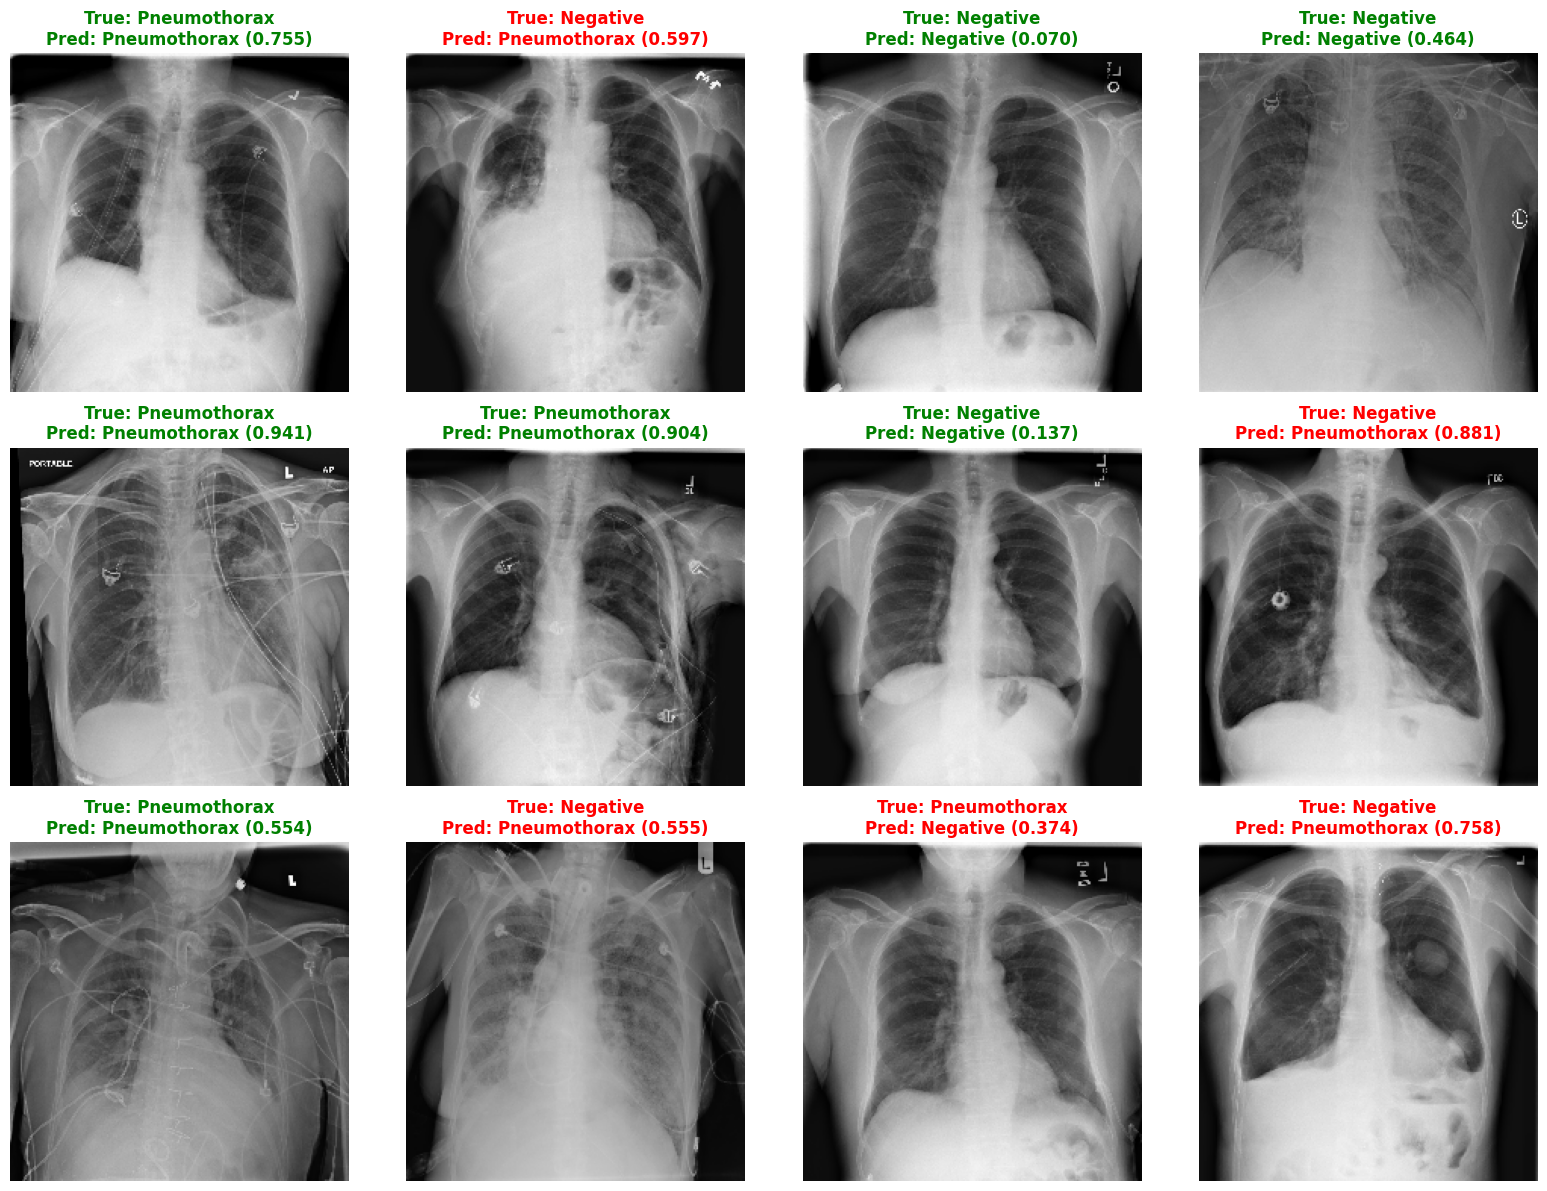

In [27]:
# ============================================================================
# VISUALIZE PREDICTIONS - FIXED
# ============================================================================

def visualize_predictions(test_df, y_pred_probs, n_samples=12):
    """Visualize sample predictions"""
    # Get sample indices
    indices = np.random.choice(len(test_df), n_samples, replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, img_idx in enumerate(indices):
        img_path = test_df.iloc[img_idx]['path']
        true_label = test_df.iloc[img_idx]['binary_label']  # FIXED: Use 'binary_label'
        pred_prob = y_pred_probs[img_idx]  # FIXED: Remove [0] since it's already 1D
        pred_label = 1 if pred_prob > 0.5 else 0
        
        # Load and display image
        img = keras.preprocessing.image.load_img(img_path, target_size=(224,224))
        img_array = keras.preprocessing.image.img_to_array(img)
        
        axes[idx].imshow(img_array.astype('uint8'))
        
        # Create title with prediction info
        true_class = "Pneumothorax" if true_label == 1 else "Negative"
        pred_class = "Pneumothorax" if pred_label == 1 else "Negative"
        color = 'green' if true_label == pred_label else 'red'
        
        title = f"True: {true_class}\nPred: {pred_class} ({pred_prob:.3f})"
        axes[idx].set_title(title, color=color, fontweight='bold')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('./output/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Get predictions on test set first
print("Generating predictions on test set...")
test_predictions = model.predict(val_dataset, verbose=1)
test_pred_probs = test_predictions.flatten()  # Already 1D

print(f"Test predictions shape: {test_pred_probs.shape}")
print(f"Test dataframe shape: {val_df.shape}")

# Visualize predictions
visualize_predictions(val_df.reset_index(drop=True), test_pred_probs)

In [28]:
# Load best model

# Evaluate on val and test
val_metrics = model.evaluate(val_dataset)
train_metrics = model.evaluate(train_dataset)

print(f"Val AUC: {val_metrics}")
print(f"Train AUC: {train_metrics}")

299/299 [==============================] - 89s 298ms/step - loss: 0.4985 - binary_accuracy: 0.7643 - auc: 0.8400 - precision: 0.7651 - recall: 0.7630
Val AUC: [0.5290329456329346, 0.7417530417442322, 0.8146057724952698, 0.7424242496490479, 0.7396226525306702]
Train AUC: [0.49845248460769653, 0.7643298506736755, 0.8399583697319031, 0.7650766968727112, 0.7629924416542053]
